# Idealista Data-Source Assessment — Rental Revenue Prediction (Madrid & Barcelona)

**Goal of this notebook.** Inventory three Kaggle Idealista datasets and decide whether they
contain what we need to build a **rental revenue** prediction model for **Madrid** and **Barcelona**.
This is the data-foundation step of a larger agentic *rent vs. Airbnb vs. sell* decision system.

**Headline question for each source:** Does it hold the *target* (monthly rent) and the *features*
(size, rooms, baths, location, property type, condition/amenities) we need?


In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from loaders import load_rent, load_madrid_sale, load_barcelona_sale
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
FIG = "../reports/figures"
import os; os.makedirs(FIG, exist_ok=True)

## 1. What each file is — listing TYPE and price scale

The single most important check: rental-revenue modelling needs **monthly rent** as the target.
A quick look at the price distributions tells us whether a file is *rent* or *sale*.

In [2]:
rent = load_rent()                 # spain rental file, deduplicated + cleaned
mad  = load_madrid_sale()           # madrid file
bcn  = load_barcelona_sale()        # barcelona richest file

summary = pd.DataFrame({
    "file": ["spain/rent_*", "madrid/Datos", "barcelona/structured"],
    "rows (dedup)": [len(rent), len(mad), len(bcn)],
    "price median (EUR)": [rent['rent_eur_month'].median(), mad['price_eur'].median(), bcn['price'].median()],
    "implied type": ["RENT / month", "SALE", "SALE"],
})
summary

,file,rows (dedup),price median (EUR),implied type
0,spain/rent_*,46826,760.0,RENT / month
1,madrid/Datos,11826,620000.0,SALE
2,barcelona/structured,14359,305000.0,SALE


**Read-out.** The Spain file's median price is ~€900 → **monthly rent**. Madrid (~€620k) and
Barcelona (~€305k) are **sale** prices (Barcelona titles literally say *"... for sale ..."*).

> **Only the Spain file carries the rental target.** The Madrid and Barcelona files are sale
> listings — feature-rich, but the wrong target for a *rental* model (useful instead for the
> *sell* arm of the project and for feature/neighbourhood reference).

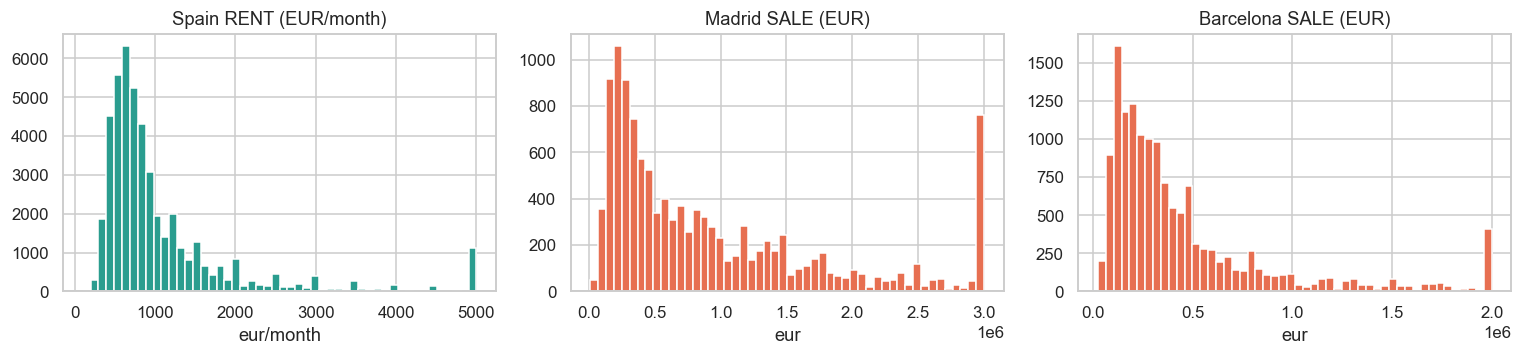

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
rent['rent_eur_month'].clip(upper=5000).hist(bins=50, ax=ax[0], color="#2a9d8f")
ax[0].set_title("Spain RENT (EUR/month)"); ax[0].set_xlabel("eur/month")
mad['price_eur'].clip(upper=3e6).hist(bins=50, ax=ax[1], color="#e76f51")
ax[1].set_title("Madrid SALE (EUR)"); ax[1].set_xlabel("eur")
bcn['price'].clip(upper=2e6).hist(bins=50, ax=ax[2], color="#e76f51")
ax[2].set_title("Barcelona SALE (EUR)"); ax[2].set_xlabel("eur")
plt.tight_layout(); plt.savefig(f"{FIG}/01_price_scales.png", bbox_inches="tight"); plt.show()

## 2. The rental dataset up close (the one that matters)

The Spain file is the only rental source, so we examine it in detail: duplication, Madrid/Barcelona
coverage, feature completeness, and what we can engineer from the free-text `title`.

In [4]:
raw = pd.read_csv("../data/raw/spain/rent_spain_scraping_dataset.csv")
raw = raw.drop(columns=[col for col in raw.columns if col.startswith('Unnamed')])
print("raw rows:", len(raw))
print("exact-duplicate rows:", raw.duplicated().sum(), f"({raw.duplicated().mean():.0%})")
print("rows after dedup:", len(raw.drop_duplicates()))

raw rows: 79749
exact-duplicate rows: 32923 (41%)
rows after dedup: 46826


In [5]:
# Madrid / Barcelona coverage after cleaning
mb = rent[rent['province'].str.lower().str.strip().isin(['madrid','barcelona'])]
cov = mb.groupby(mb['province'].str.lower().str.strip()).agg(
    listings=('rent_eur_month','size'),
    rent_median=('rent_eur_month','median'),
    sqm_median=('sq_m','median'),
    rooms_median=('n_rooms','median'),
)
cov

,listings,rent_median,sqm_median,rooms_median
province,,,,
barcelona,1789,1500.0,85.0,3.0
madrid,1773,1200.0,80.0,2.0


In [6]:
# feature completeness of the rental file
comp = pd.DataFrame({
    "non_null_%": (rent.notna().mean()*100).round(1),
}).sort_values("non_null_%", ascending=False)
comp

,non_null_%
province,100.0
region,100.0
title,100.0
rent_eur_month,100.0
property_type,100.0
scrape_pool_size,100.0
municipality,100.0
sq_m,99.1
eur_per_sqm,99.1
n_rooms,96.6


### What we can engineer from `title`

The raw file has very few columns, but the `title` string encodes **property type** and
**municipality** — we extract both in `loaders.py`.

In [7]:
mb[['title','property_type','municipality','rent_eur_month','n_rooms','sq_m','eur_per_sqm']].head(8)

,title,property_type,municipality,rent_eur_month,n_rooms,sq_m,eur_per_sqm
9979,"Piso en passatge can curt, 11, Pere Garau, Pal...",flat,Palma de Mallorca,895.0,1.0,67.0,13.358209
9980,"Ático en Montcades, 3, Monti-Sión, Palma de Ma...",other,Palma de Mallorca,1300.0,2.0,100.0,13.000000
9981,Casa o chalet independiente en calle de s'Anfó...,house,Sant Lluis,6000.0,3.0,120.0,50.000000
9982,"Piso en Son Serra - La Vileta - Son Pereto, Pa...",flat,Palma de Mallorca,700.0,1.0,45.0,15.555556
9983,"Ático en avenida 8 de Agosto, Marina Botafoc -...",other,Eivissa,4550.0,3.0,150.0,30.333333
9984,Casa o chalet independiente en Alaró,house,Casa o chalet independiente en Alaró,1300.0,3.0,100.0,13.000000
9985,"Casa o chalet independiente en Pla de na Tesa,...",house,Marratxi,5000.0,5.0,743.0,6.729475
9986,"Piso en Son Dameto, Palma de Mallorca",flat,Palma de Mallorca,1090.0,3.0,120.0,9.083333


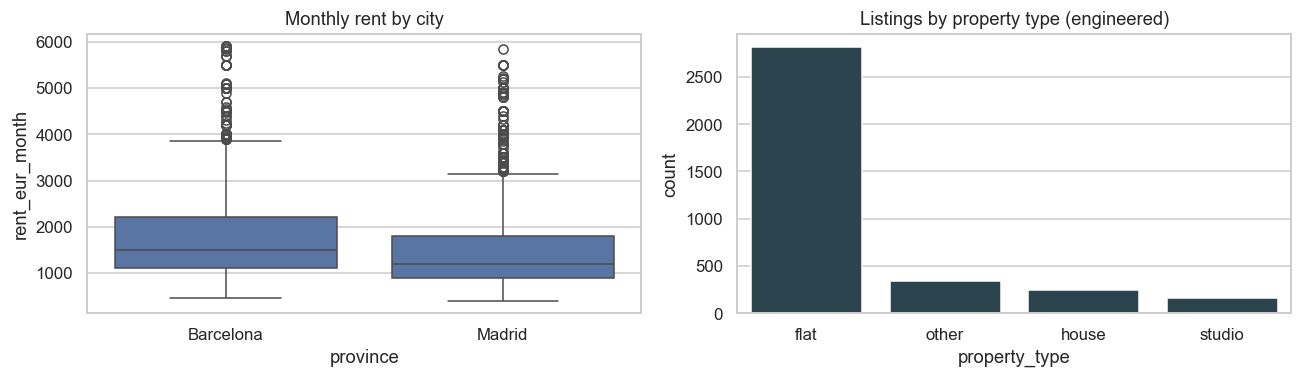

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
sns.boxplot(data=mb[mb['rent_eur_month']<6000], x='province', y='rent_eur_month', ax=ax[0])
ax[0].set_title("Monthly rent by city")
order = mb['property_type'].value_counts().index
sns.countplot(data=mb, x='property_type', order=order, ax=ax[1], color="#264653")
ax[1].set_title("Listings by property type (engineered)")
plt.tight_layout(); plt.savefig(f"{FIG}/02_rent_by_city_type.png", bbox_inches="tight"); plt.show()

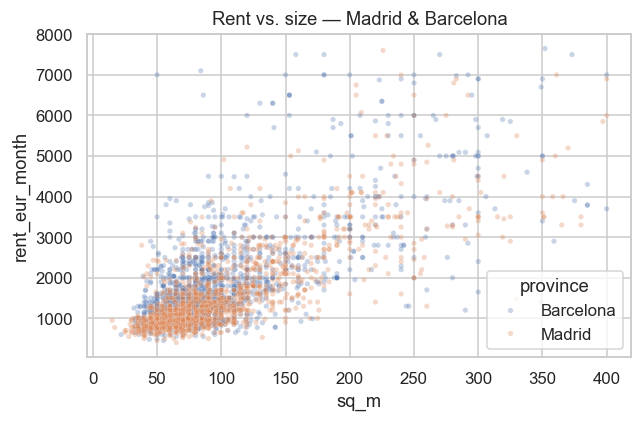

corr(sq_m, rent): 0.723


In [9]:
# rent vs size relationship (sanity: should be positive)
g = mb[(mb['sq_m'].between(15,400)) & (mb['rent_eur_month']<8000)]
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=g, x='sq_m', y='rent_eur_month', hue='province', alpha=.3, s=12, ax=ax)
ax.set_title("Rent vs. size — Madrid & Barcelona"); plt.tight_layout()
plt.savefig(f"{FIG}/03_rent_vs_size.png", bbox_inches="tight"); plt.show()
print("corr(sq_m, rent):", g[['sq_m','rent_eur_month']].corr().iloc[0,1].round(3))

## 3. The SALE datasets — what features they offer (for reference / the *sell* arm)

Even though these are the wrong *target* for rental, they are far richer in features and will be
valuable for (a) the *sell* side of the rent/Airbnb/sell decision and (b) neighbourhood-level
context. Here is what they add beyond the rental file.

In [10]:
print("MADRID sale columns:\n", list(mad.columns))
print("\nBARCELONA sale columns:\n", list(bcn.columns))

MADRID sale columns:
 ['province', 'district', 'title', 'price_eur', 'price_prev_eur', 'sq_m', 'n_rooms', 'lift', 'orientation', 'floor', 'baños', 'tags', 'descripcion', 'Enlace']

BARCELONA sale columns:
 ['id', 'property_type', 'adress', 'neighborhood', 'city', 'price', 'sq_m_built', 'sq_m_floor_area', 'n_bedrooms', 'bathrooms', 'floor_y', 'year_built', 'exterior_x', 'lift_x', 'terrace', 'balcony', 'second hand', 'needs renovating', 'parking', 'swimming pool', 'garden', 'air conditioning', 'heating', 'central_heating', 'heating_type', 'consumption_in_mkw/m2_year', 'emissions_in_kgco2/m2_year', 'orientation', 'description']


In [11]:
feature_matrix = pd.DataFrame(
    index=["rent target","sale price","size m2","rooms","bathrooms","neighborhood/district",
           "property type","floor","year built","condition/renov","amenities (lift/AC/terrace...)",
           "energy cert","lat/long","free-text description"],
    data={
      "spain RENT":   ["YES","-","yes","yes","-","city only*","engineered*","-","-","-","-","-","-","-"],
      "madrid SALE":  ["-","YES","yes","yes","yes","district","title*","yes","-","tags*","partial","-","-","yes"],
      "barcelona SALE":["-","YES","yes","yes","yes","neighborhood","yes","yes","partial","yes","YES","yes","-","yes"],
    })
feature_matrix

,spain RENT,madrid SALE,barcelona SALE
rent target,YES,-,-
sale price,-,YES,YES
size m2,yes,yes,yes
rooms,yes,yes,yes
bathrooms,-,yes,yes
neighborhood/district,city only*,district,neighborhood
property type,engineered*,title*,yes
floor,-,yes,yes
year built,-,-,partial
condition/renov,-,tags*,yes


\*  engineered from free text or partially present.

## 4. Verdict

| Source | Type | Madrid+BCN usable rows | Target for rental model? | Role in project |
|---|---|---|---|---|
| **spain/rent_** | RENT | ~3.5k (post-dedup) | **Yes — only source with rent** | Train the rental-revenue MVP |
| madrid/Datos | SALE | ~11.8k | No (sale) | *Sell* arm; feature/price reference |
| barcelona/structured | SALE | ~14.4k | No (sale) | *Sell* arm; richest feature schema |

**Bottom line.** We *can* build a baseline rental-revenue model from the Spain file
(`rent ~ city + property_type + rooms + m²`, plus engineered municipality), but it is
**feature-thin and small (~3.5k unique Madrid/BCN rows)** with **no bathrooms, amenities, or
neighbourhood granularity**. To reach production quality we will likely need **additional rental
data** (a targeted idealista rentals scrape, or a richer rental dataset). The two sale datasets do
not solve the rental target but are strong assets for the *sell* comparison and for transferring
feature/neighbourhood structure.
